### Time Series- Window Functions: Rolling and Expanding

In time series analysis, we often don't want to analyze the entire dataset at once, nor just a single data point in isolation. Instead, we look at **windows** of data to calculate aggregate statistics (like the mean, sum, or standard deviation).

There are two primary types of windows: **Rolling** (Moving) and **Expanding** (Cumulative).

---

#### 1. Rolling Windows (The "Sliding" Window)

**Concept:**
A rolling window is a fixed-size window that "slides" over your data as time progresses. At any specific time step $t$, the window includes the current point and the previous $n-1$ points.

* **Window Size:** Constant (e.g., a 7-day window).
* **Behavior:** As a new data point enters the window, the oldest data point drops out.



**Why use it?**
* **Smoothing:** It removes short-term fluctuations (noise) to highlight longer-term trends.
* **Volatility Analysis:** Calculating the rolling standard deviation (Bollinger Bands) to see how stability changes over time.
* **Local Context:** It answers: *"How are we doing compared to the recent past?"*

**The Math (Simplified):**
For a rolling mean with a window size of $k$ at time $t$, the calculation is:

$$
\mu_t = \frac{x_t + x_{t-1} + ... + x_{t-k+1}}{k}
$$

> **Analogy:** Imagine looking at a long train through a small, fixed-size window frame in a wall. As the train moves, you always see the same *amount* of the train (e.g., 2 cars), but the specific cars you see are constantly changing.

---

#### 2. Expanding Windows (The "Growing" Window)

**Concept:**
An expanding window is anchored at the start of the time series. The window size grows with each new time step. At time step $t$, the window includes **all** data points from the start ($t=0$) up to the current moment.

* **Window Size:** Increases by 1 at every step.
* **Behavior:** No data ever drops out; it accumulates history.



**Why use it?**
* **Cumulative Metrics:** Calculating "Year-to-Date" (YTD) revenue or "Life-to-Date" sales.
* **Convergence:** Seeing how an average stabilizes as more data is collected.
* **Global Context:** It answers: *"What is the summary of our performance from the very beginning up to now?"*

**The Math (Simplified):**
For an expanding mean at time $t$ (where the series starts at $t=0$), the calculation is:

$$
\mu_t = \frac{\sum_{i=0}^{t} x_i}{t+1}
$$

> **Analogy:** Imagine rolling a snowball down a snowy hill. It starts small, but as it rolls forward, it collects more and more snow. The snowball represents your window—it keeps getting bigger and containing more "history" as it moves.

---

## ⚡ Quick Comparison

| Feature | Rolling Window | Expanding Window |
| :--- | :--- | :--- |
| **Size** | Fixed (e.g., 7 days) | Variable (Grows continuously) |
| **Old Data** | Dropped as new data arrives | Retained forever |
| **Main Use** | Trend Smoothing, Noise Reduction | Cumulative Sums, Lifetime Averages |
| **Pandas Syntax** | `.rolling(window=n)` | `.expanding(min_periods=n)` |

In [1]:
import pandas as pd
df = pd.read_csv('starbucks.csv', index_col= 'Date', parse_dates= True)

In [2]:
df.head()

,Close,Volume
Date,,
2015-01-02,38.0061,6906098
2015-01-05,37.2781,11623796
2015-01-06,36.9748,7664340
2015-01-07,37.8848,9732554
2015-01-08,38.4961,13170548


In [3]:
df.shape

(1006, 2)

<Axes: xlabel='Date'>

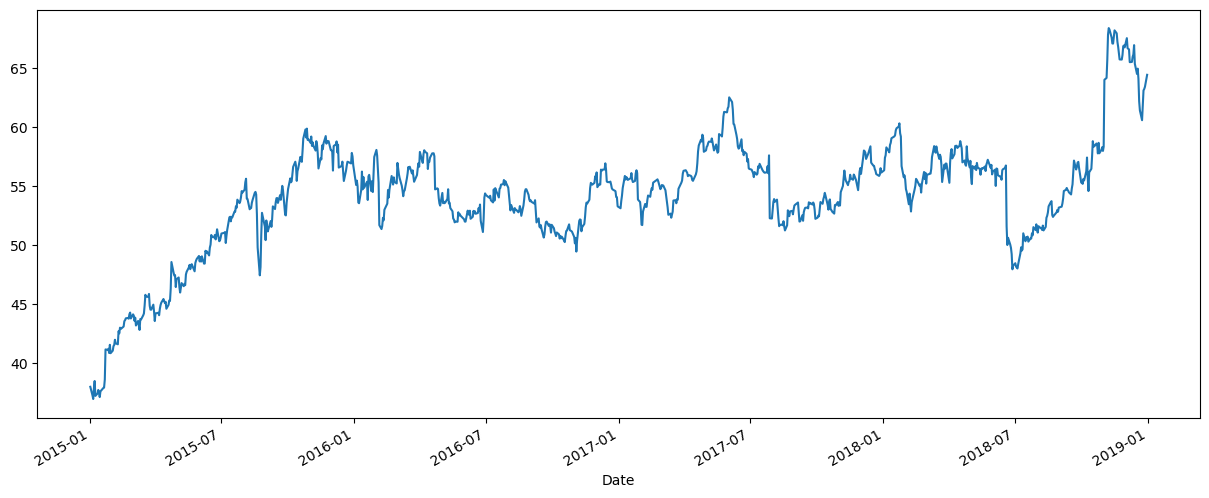

In [5]:
df['Close'].plot(kind= 'line', figsize= (15,6))

**Plotting Daily Close Price and Moving Average of Last One Week:**

In [6]:
df['Close: One Week Moving Average'] = df['Close'].rolling(window= 7).mean()

In [7]:
df.head(10)

,Close,Volume,Close: One Week Moving Average
Date,,,
2015-01-02,38.0061,6906098,NaN
2015-01-05,37.2781,11623796,NaN
2015-01-06,36.9748,7664340,NaN
2015-01-07,37.8848,9732554,NaN
2015-01-08,38.4961,13170548,NaN
2015-01-09,37.2361,27556706,NaN
2015-01-12,37.4415,10021486,37.616786
2015-01-13,37.7401,11040702,37.578786
2015-01-14,37.5301,9295084,37.614786


<Axes: xlabel='Date'>

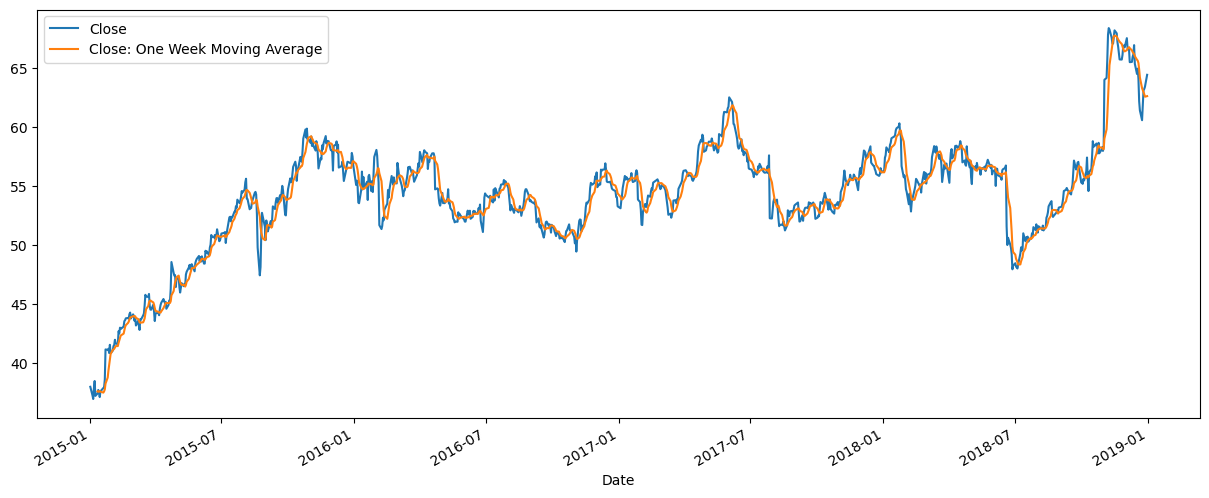

In [8]:
df[['Close', 'Close: One Week Moving Average']].plot(kind= 'line', figsize= (15,6))

**Plotting Daily Close Price and Moving Average of Last One Month:**

<Axes: xlabel='Date'>

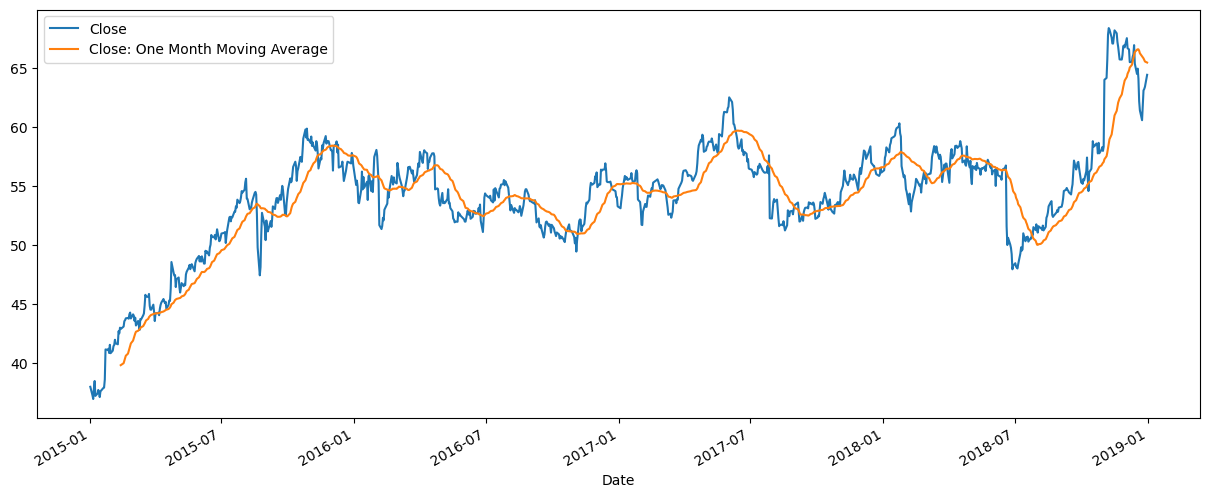

In [9]:
df['Close: One Month Moving Average'] = df['Close'].rolling(window= 30).mean()
df[['Close', 'Close: One Month Moving Average']].plot(kind= 'line', figsize= (15,6))

**Plotting Daily Close Price and Cummulative Average of Close Price:**

<Axes: xlabel='Date'>

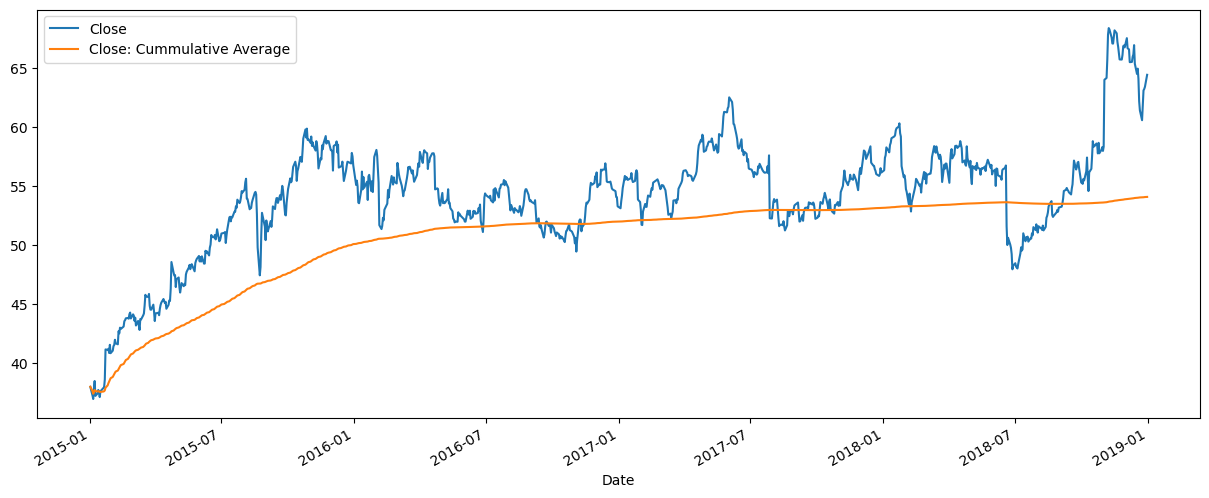

In [10]:
df['Close: Cummulative Average'] = df['Close'].expanding(min_periods= 1).mean()
df[['Close', 'Close: Cummulative Average']].plot(kind= 'line', figsize= (15,6))

In [12]:
df.head(10)

,Close,Volume,Close: One Week Moving Average,Close: One Month Moving Average,Close: Cummulative Average
Date,,,,,
2015-01-02,38.0061,6906098,NaN,NaN,38.006100
2015-01-05,37.2781,11623796,NaN,NaN,37.642100
2015-01-06,36.9748,7664340,NaN,NaN,37.419667
2015-01-07,37.8848,9732554,NaN,NaN,37.535950
2015-01-08,38.4961,13170548,NaN,NaN,37.727980
2015-01-09,37.2361,27556706,NaN,NaN,37.646000
2015-01-12,37.4415,10021486,37.616786,NaN,37.616786
2015-01-13,37.7401,11040702,37.578786,NaN,37.632200
2015-01-14,37.5301,9295084,37.614786,NaN,37.620856
